## Compute atmospheric carbon mass 

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Check if co2mass exists as a variable

In [2]:
models = ['ACCESS-ESM1-5']#['CESM2']#['MIROC-ES2L']#['IPSL-CM6-ESMCO2']#['GFDL-ESM2M']#['GISSE2.1-G-CC2']#['GFDL-ESM2M']#['NorESM2-LM']#['IPSL-CM6-ESMCO2','GFDL-ESM2M','NorESM2-LM','UKESM1-2','EC-Earth3-ESM-1','GISSE2.1-G-CC2']
runs = pruns.get_run_list('tipmip_tier1')[:1]#[-1:]#[-2:]#[:1] #[1:]
outroot = './../01_postprocessed_data/global_time_series'

def get_freq_input(model):
    if model == 'GISSE2.1-G-CC2':
        freq_input = 'yearly'
    else:
        freq_input = 'monthly'
    return freq_input

#def get_stat(varia,default=True):
#    if default == True:
#        if varia in ['ps']:
#            stat = 'integral'
#        elif varia in ['co2mass']:
#            stat = None
#    else:
#        stat = 'integral'
#    return stat

#def calc_horizontal_stat(da, area_weights, stat, mask=None, dims=None,grid_cell_fractions=None):
#    if stat == 'mean':
#        da_stat = SpaceOperator.calc_spatial_mean(da, area_weights, mask=mask, dims=dims, grid_cell_fractions=grid_cell_fractions)
#    elif stat == 'integral':
#        da_stat = SpaceOperator.calc_spatial_integral(da, area_weights, mask=mask, dims=dims, grid_cell_fractions=grid_cell_fractions)
#    return da_stat

In [3]:
from dask.distributed import Client
client = Client()

/net/nfs/tools/u20/Python/miniconda3_py311_23.11.0-2/envs/pangeo-meso-2024.01.22/lib/python3.11/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44729 instead
  warnings.warn(


In [4]:
client
#port = client.scheduler_info()["services"]["dashboard"]
#prefix = os.environ.get("JUPYTERHUB_SERVICE_PREFIX", "/")
#proxy_url = f"https://jupyterhub.dkrz.de/{prefix}proxy/{port}/status"
#print(proxy_url)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:44729/status,
Dashboard: http://127.0.0.1:44729/status,Workers: 8
Total threads: 40,Total memory: 80.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45501,Workers: 8
Dashboard: http://127.0.0.1:44729/status,Total threads: 40
Started: Just now,Total memory: 80.00 GiB
Comm: tcp://127.0.0.1:45309,Total threads: 5
Dashboard: http://127.0.0.1:46721/status,Memory: 10.00 GiB
Nanny: tcp://127.0.0.1:43257,


ACCESS-ESM1-5: need to infer co2mass.
esm-piControl
... getting area weights.
... saving under ./../01_postprocessed_data/global_time_series/co2mass/ACCESS-ESM1-5/esm-piControl/r1i1p1f1/monthly/global_None/co2mass_ACCESS-ESM1-5_esm-piControl_r1i1p1f1_global_None.nc


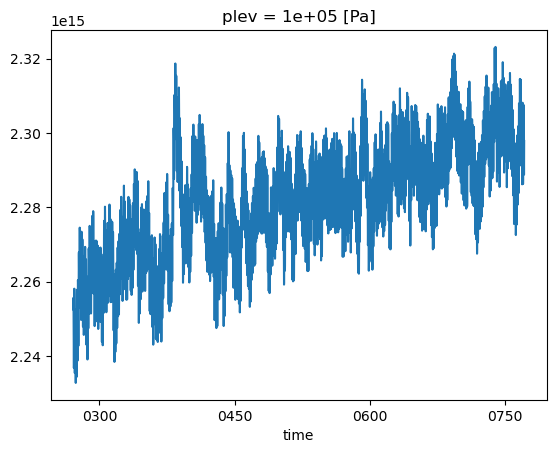

In [5]:
for model in models:
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    freq_input = get_freq_input(model)
    infix = ''
    if model == 'MIROC-ES2L':
        stat = 'mean'
    else:
        stat = None
    
    if model in ['IPSL-CM6-ESMCO2','GISSE2.1-G-CC2']:
        print(f'{model}: co2mass available. Nothing to do...')
        need_to_infer = False
    else:
        print(f'{model}: need to infer co2mass.')
        need_to_infer = True

    if need_to_infer:
        
        if model == 'GFDL-ESM2M':

            varia = 'co2'
            domain = mgrab.get_domain(varia,freq_input)
            
            for run in runs:
                PSTD_MKS = 101325.0
                PI = 3.14159265358979323846
                GRAV = 9.80
                RADIUS = 6371000
                M_atm = PSTD_MKS*(4*PI*RADIUS**2)/GRAV
                #M_atm = 5.15e18 # kg
                #M_atm = 5.08e18 # kg
                M_air = 28.89644*(10**(-3)) # kg/mol
                M_C = 12.*(10**(-3)) #kg/mol
                files = glob.glob(f'/projets/TipESM/UBERN/TipESM/GFDL-ESM2M/{run}/r1i1p1f1/Amon/{varia}/gn/v*/{varia}*.nc')
                ds = xr.open_mfdataset(files,use_cftime=True)
                ppmv = ds[varia]
                conversion_factor = 1e-6 * M_C/M_air * M_atm # ~2.19 PgC muatm-1     / 1000 / 1000 / 1000 / 1000 # in gC
                conversion_factor = 2.123*1e12 #2.123*1e12 # PgC muatm-1, as done by Friedrich Burger
                cmass = ppmv * conversion_factor 
                
                M_CO2 = 44.00995*(10**(-3))#44.011*(10**(-3))
                co2mass = cmass*M_CO2/M_C # in kgCO2
                co2mass.plot();     

                # make consistent with IPSL model output
                co2mass_1d = co2mass.squeeze("scalar_axis", drop=True)
                co2mass_1d = co2mass_1d.rename("co2mass_global_None")
                co2mass_1d.attrs["standard_name"] = 'atmosphere_mass_of_carbon_dioxide'
                co2mass_1d.attrs["long_name"] = 'Total Atmospheric Mass of CO2'
                co2mass_1d.attrs["comment"] = 'Total atmospheric mass of Carbon Dioxide'
                co2mass_1d.attrs["units"] = 'kg'
                co2mass_1d.attrs["original name"] = 'co2'
                co2mass_1d.attrs["history"] = f'manually converted from co2 (in ppmv), using cmass_in_kg = co2_in_ppmv*10**-6*M_atm/M_air*M_C, with M_atm = {M_atm}kg, M_air = {M_air}kg/mol, M_C = {M_C}kg/mol. Then further converted cmass to co2mass using co2mass=cmass*M_CO2/M_C with M_CO2 = {M_CO2} kg/mol.'
                co2mass_out = co2mass_1d.to_dataset()

                save_dir = f'{outroot}/co2mass/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}'
                os.makedirs(save_dir,exist_ok=True)
                save_string = f'{save_dir}/co2mass_{model}_{run}_{member}_{infix}global_{stat}.nc'
                print(f'... saving under {save_string}')
                co2mass_out.to_netcdf(save_string)


        elif model == 'MIROC-ES2L':

            varia = 'co2s'
            domain = mgrab.get_domain(varia,freq_input)
            
            for run in runs:
                PSTD_MKS = 101325.0
                PI = 3.14159265358979323846
                GRAV = 9.80
                RADIUS = 6371000
                M_atm = PSTD_MKS*(4*PI*RADIUS**2)/GRAV
                ##M_atm = 5.15e18 # kg
                ##M_atm = 5.08e18 # kg
                M_air = 28.89644*(10**(-3)) # kg/mol
                M_C = 12.*(10**(-3)) #kg/mol
                conversion_factor = 1e-6 * M_C/M_air * M_atm # ~2.19 PgC muatm-1     / 1000 / 1000 / 1000 / 1000 # in gC
                #conversion_factor = 2.123*1e12 #2.123*1e12 # PgC muatm-1, as done by Friedrich Burger

                print(f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}/{varia}*.nc')
                files = glob.glob(f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}/{varia}*.nc')
                ds = xr.open_mfdataset(files,use_cftime=True)
                ppmv = ds[f'{varia}_global_{stat}']
                cmass = ppmv * conversion_factor 
                
                M_CO2 = 44.00995*(10**(-3))#44.011*(10**(-3))
                co2mass = cmass*M_CO2/M_C # in kgCO2
                co2mass.plot();     

                # make consistent with IPSL model output
                #co2mass_1d = co2mass.squeeze("scalar_axis", drop=True)
                newstat = 'None'
                co2mass_1d = co2mass.rename(f"co2mass_global_{newstat}")
                co2mass_1d.attrs["standard_name"] = 'atmosphere_mass_of_carbon_dioxide'
                co2mass_1d.attrs["long_name"] = 'Total Atmospheric Mass of CO2'
                co2mass_1d.attrs["comment"] = 'Total atmospheric mass of Carbon Dioxide'
                co2mass_1d.attrs["units"] = 'kg'
                co2mass_1d.attrs["original name"] = 'co2s'
                co2mass_1d.attrs["history"] = f'manually converted from co2s (in ppmv), using cmass_in_kg = co2_in_ppmv*10**-6*M_atm/M_air*M_C, with M_atm = {M_atm}kg, M_air = {M_air}kg/mol, M_C = {M_C}kg/mol. Then further converted cmass to co2mass using co2mass=cmass*M_CO2/M_C with M_CO2 = {M_CO2} kg/mol.'
                co2mass_out = co2mass_1d.to_dataset()

                save_dir = f'{outroot}/co2mass/{model}/{run}/{member}/{freq_input}/{infix}global_{newstat}'
                os.makedirs(save_dir,exist_ok=True)
                save_string = f'{save_dir}/co2mass_{model}_{run}_{member}_{infix}global_{newstat}.nc'
                print(f'... saving under {save_string}')
                co2mass_out.to_netcdf(save_string)

        
        elif model == 'NorESM2-LM':

            varia = 'co2'
            domain = mgrab.get_domain(varia,freq_input)
            
            for run in runs:
                print(run)
                M_atm = 5.15e18 # kg
                M_air = 28.97*(10**(-3)) # kg/mol
                M_C = 12.0107*(10**(-3)) #kg/mol
                if run == 'esm-piControl':
                    files = sorted(glob.glob(f"/projets/TipESM/UiB/NorESM2-LM/{run.replace('gwl','swl')}/{varia}_AERmon*.nc"))
                else:
                    files = sorted(glob.glob(f"/projets/TipESM/UiB/NorESM2-LM/{run.replace('gwl','swl')}/v*/{varia}_AERmon*.nc"))
                ds = xr.open_mfdataset(files,use_cftime=True)
                ppm = ds[varia].isel(lev=0)#.load()  # mole fraction at surface (should ideally be a vertical integral)
                if run == 'esm-piControl':
                    ppm = ppm-145*10**-6 #
                # get the area_weights
                print(f'... getting area weights.')
                mgrab = MODELgrabber.get_grabber(model)
                area_weights = mgrab.get_area(varia,freq_input)
                molar_fraction = SpaceOperator.calc_spatial_mean(ppm, area_weights, mask=None, dims=None, grid_cell_fractions=None)
                cmass = molar_fraction * M_atm / M_air * M_C # in kgC     / 1000 / 1000 / 1000 / 1000 # in gC
                M_CO2 = 44.011*(10**(-3))
                co2mass = cmass*M_CO2/M_C # in kgCO2
                co2mass.plot();     

                # make consistent with IPSL model output
                co2mass_1d = co2mass.drop_vars("lev")
                co2mass_1d = co2mass_1d.rename("co2mass_global_None")
                co2mass_1d.attrs["standard_name"] = 'atmosphere_mass_of_carbon_dioxide'
                co2mass_1d.attrs["long_name"] = 'Total Atmospheric Mass of CO2'
                co2mass_1d.attrs["comment"] = 'Total atmospheric mass of Carbon Dioxide'
                co2mass_1d.attrs["units"] = 'kg'
                co2mass_1d.attrs["original name"] = 'co2'
                co2mass_1d.attrs["history"] = f'manually converted from co2 (mole fraction), using cmass_in_kg = co2_mole_fraction*M_atm/M_air*M_C, with M_atm = {M_atm}kg, M_air = {M_air}kg/mol, M_C = {M_C}kg/mol. Then further converted cmass to co2mass using co2mass=cmass*M_CO2/M_C with M_CO2 = {M_CO2} kg/mol.'
                co2mass_out = co2mass_1d.to_dataset()

                save_dir = f'{outroot}/co2mass/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}'
                os.makedirs(save_dir,exist_ok=True)
                save_string = f'{save_dir}/co2mass_{model}_{run}_{member}_{infix}global_{stat}.nc'
                print(f'... saving under {save_string}')
                co2mass_out.to_netcdf(save_string)

        elif model == 'CESM2':

            varia = 'CO2'
            domain = mgrab.get_domain(varia,freq_input)

            for run in runs:
                print(run)
                M_atm = 5.1352e18 # kg, dry weight of atmosphere
                files = sorted(glob.glob(f"/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.{run}.001/atm/proc/tseries/month_1/b.e21.B1850.f09_g17.{run}.001.cam.h*.{varia}.*.nc"))
                ds = xr.open_mfdataset(files,use_cftime=True)
                dry_mass_mixing_ratio = ds[varia].isel(lev=-1) #.load()  # mass mixing ratio at surface (should ideally be a vertical integral)
                # get the area_weights
                print(f'... getting area weights.')
                mgrab = MODELgrabber.get_grabber(model)
                area_weights = mgrab.get_area(varia,freq_input)
                mean_mass_mixing_ratio = SpaceOperator.calc_spatial_mean(dry_mass_mixing_ratio, area_weights, mask=None, dims=None, grid_cell_fractions=None)
                co2mass = mean_mass_mixing_ratio * M_atm # in kgCO2     / 1000 / 1000 / 1000 / 1000 # in gC
                #M_C = 12.0107*(10**(-3)) #kg/mol
                #M_CO2 = 44.011*(10**(-3))
                #co2mass = cmass*M_CO2/M_C # in kgCO2
                co2mass.plot();     

                # make consistent with IPSL model output
                co2mass_1d = co2mass.drop_vars("lev")
                co2mass_1d = co2mass_1d.rename("co2mass_global_None")
                co2mass_1d.attrs["standard_name"] = 'atmosphere_mass_of_carbon_dioxide'
                co2mass_1d.attrs["long_name"] = 'Total Atmospheric Mass of CO2'
                co2mass_1d.attrs["comment"] = 'Total atmospheric mass of Carbon Dioxide'
                co2mass_1d.attrs["units"] = 'kg'
                co2mass_1d.attrs["original name"] = 'co2'
                co2mass_1d.attrs["history"] = f'manually converted from CO2 (mass mixing ratio), using co2mass_in_kg = mass_mixing_ratio*M_atm, with M_atm = {M_atm}kg.'
                co2mass_out = co2mass_1d.to_dataset()

                save_dir = f'{outroot}/co2mass/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}'
                os.makedirs(save_dir,exist_ok=True)
                save_string = f'{save_dir}/co2mass_{model}_{run}_{member}_{infix}global_{stat}.nc'
                print(f'... saving under {save_string}')
                co2mass_out.to_netcdf(save_string)

        elif model == 'ACCESS-ESM1-5':

            varia = 'co2'
            domain = mgrab.get_domain(varia,freq_input)
            
            for run in runs:
                print(run)
                M_atm = 5.15e18 # kg
                M_air = 28.97*(10**(-3)) # kg/mol
                M_C = 12.0107*(10**(-3)) #kg/mol
                if run == 'esm-piControl':
                    files = sorted(glob.glob(f"/bdd/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/{run}/r1i1p1f1/Amon/co2/gn/latest/co2_*.nc"))
                else:
                    files = sorted(glob.glob(f"/work/bm1448/upload/tipesm/ACCESS-ESM1-5/{run}/r1i1p1f1/Amon/co2/v*/co2_*.nc"))
                ds = xr.open_mfdataset(files,use_cftime=True)
                ppm = ds[varia].isel(plev=0).persist()  # mole fraction at surface (should ideally be a vertical mean)
                print(f'... getting area weights.')
                mgrab = MODELgrabber.get_grabber(model)
                area_weights = mgrab.get_area(varia,freq_input)
                molar_fraction = SpaceOperator.calc_spatial_mean(ppm, area_weights, mask=None, dims=None, grid_cell_fractions=None)
                cmass = molar_fraction * M_atm / M_air * M_C # in kgC     / 1000 / 1000 / 1000 / 1000 # in gC
                M_CO2 = 44.011*(10**(-3))
                co2mass = cmass*M_CO2/M_C # in kgCO2
                co2mass.plot();     

                # make consistent with IPSL model output
                co2mass_1d = co2mass.drop_vars("plev")
                co2mass_1d = co2mass_1d.rename("co2mass_global_None")
                co2mass_1d.attrs["standard_name"] = 'atmosphere_mass_of_carbon_dioxide'
                co2mass_1d.attrs["long_name"] = 'Total Atmospheric Mass of CO2'
                co2mass_1d.attrs["comment"] = 'Total atmospheric mass of Carbon Dioxide'
                co2mass_1d.attrs["units"] = 'kg'
                co2mass_1d.attrs["original name"] = 'co2'
                co2mass_1d.attrs["history"] = f'manually converted from co2 (mole fraction), using cmass_in_kg = co2_mole_fraction*M_atm/M_air*M_C, with M_atm = {M_atm}kg, M_air = {M_air}kg/mol, M_C = {M_C}kg/mol. Then further converted cmass to co2mass using co2mass=cmass*M_CO2/M_C with M_CO2 = {M_CO2} kg/mol.'
                co2mass_out = co2mass_1d.to_dataset()

                save_dir = f'{outroot}/co2mass/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}'
                os.makedirs(save_dir,exist_ok=True)
                save_string = f'{save_dir}/co2mass_{model}_{run}_{member}_{infix}global_{stat}.nc'
                print(f'... saving under {save_string}')
                co2mass_out.to_netcdf(save_string)

            
            plt.show()
            